# 1 - Read the WAV file



In [3]:
import struct
import numpy as np
import matplotlib.pyplot as plt

def load_audio(file_path):
    sample_rate = 0
    sample_width = 0
    with open(file_path,'rb') as audio_file:
        header = audio_file.read(44)
        print(f"The header is {header}")
        if header[:4] != b'RIFF' or header[8:12] != b'WAVE' or header[12:16] != b'fmt ':
            raise ValueError("Invalid WAV file")
        header_chunk_id = struct.unpack('4s', header[0:4])[0]
        header_chunk_size = struct.unpack('<I', header[4:8])[0]
        header_chunk_format = struct.unpack('4s', header[8:12])[0]
        format_chunk_id = struct.unpack('4s', header[12:16])[0]
        format_chunk_size = struct.unpack('<I', header[16:20])[0]
        format_code = struct.unpack('<H', header[20:22])[0]
        channels = struct.unpack('<H', header[22:24])[0]
        sample_rate = struct.unpack('<I', header[24:28])[0]
        byte_rate = struct.unpack('<I', header[28:32])[0]
        block_align = struct.unpack('<H', header[32:34])[0]
        sample_width = struct.unpack('<H', header[34:36])[0]
        print(sample_width)
        data_chunk_id = struct.unpack('4s', header[36:40])[0]
        data_chunk_size = struct.unpack('<I', header[40:44])[0]
        audio_file.seek(44)
        data = audio_file.read(data_chunk_size)
    data_array = np.frombuffer(data, dtype=np.int16)

    data_array = np.frombuffer(data, dtype=np.int32)
    data_array = data_array.astype(np.float32)
    return sample_rate,data_array

In [16]:
import struct
import numpy as np

def read_wav(file_path):
    sample_rate = 0
    sample_width = 0
    with open(file_path, 'rb') as f:
        # Read RIFF header
        riff_id = f.read(4)
        if riff_id != b'RIFF':
            raise ValueError("Not a RIFF file.")
        chunk_size = int.from_bytes(f.read(4), 'little')
        format = f.read(4)
        if format != b'WAVE':
            raise ValueError("Not a WAVE file.")
        
        # Mamaky fmt 
        fmt_id = f.read(4)
        if fmt_id != b'fmt ':
            raise ValueError("fmt chunk not found.")
        fmt_size = int.from_bytes(f.read(4), 'little')
        fmt_data = f.read(fmt_size)
        
        # Mak fmt data
        if len(fmt_data) < 16:
            raise ValueError("Invalid fmt chunk size.")
        audio_format = int.from_bytes(fmt_data[0:2], 'little')
        num_channels = int.from_bytes(fmt_data[2:4], 'little')
        sample_rate = int.from_bytes(fmt_data[4:8], 'little')
        bits_per_sample = int.from_bytes(fmt_data[14:16], 'little')
        sample_width = bits_per_sample // 8  # sample width in bytes

        if audio_format != 1:
            raise ValueError("Only PCM audio format is supported.")
        
        # Maka data chunk
        while True:
            chunk_id = f.read(4)
            if not chunk_id:
                raise ValueError("data chunk not found.")
            if chunk_id == b'data':
                data_size = int.from_bytes(f.read(4), 'little')
                data = f.read(data_size)
                break
            else:
                chunk_size = int.from_bytes(f.read(4), 'little')
                f.seek(chunk_size, 1)
        
        # Mamadika bytes ho array
        bytes_per_sample = bits_per_sample // 8
        num_samples = len(data) // bytes_per_sample
        samples = []
        
        for i in range(num_samples):
            start = i * bytes_per_sample
            end = start + bytes_per_sample
            sample_bytes = data[start:end]
            if bits_per_sample == 8:
                sample = int.from_bytes(sample_bytes, 'little', signed=False) - 128
            else:
                sample = int.from_bytes(sample_bytes, 'little', signed=True)
            samples.append(sample)
        print("IS STEREO",num_channels)
        if num_channels > 1:
            channels = [[] for _ in range(num_channels)]
            for idx, sample in enumerate(samples):
                channel = idx % num_channels
                channels[channel].append(sample)

            for ch_idx in range(num_channels):
                channels[ch_idx] = np.array(channels[ch_idx], dtype=np.float32)

            return {
                'sample_rate': sample_rate,
                'sample_width': sample_width,
                'num_channels': num_channels,
                'samples': channels
            }
        else:
            samples = np.array(samples, dtype=np.float32)
            return {
                'sample_rate': sample_rate,
                'sample_width': sample_width,
                'num_channels': num_channels,
                'samples': samples
            }



## Audi plot

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


IS STEREO 1
[ 0.  0.  0. ... 51. 11. -7.]


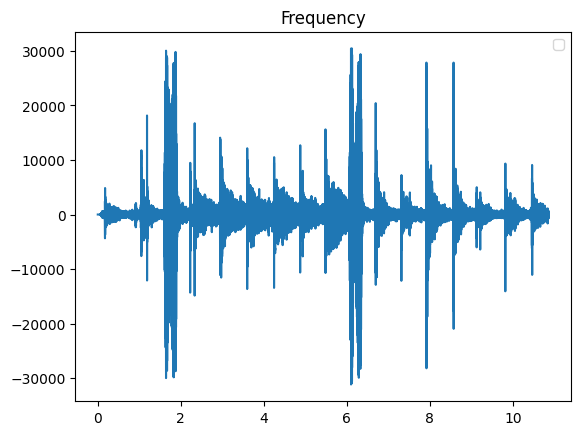

In [18]:
def plot_audio(file_path):
    sample_rate,data_array = load_audio(file_path)
    print(data_array)
    x_axis = np.arange(0,len(data_array)) / sample_rate
    plt.plot(x_axis,data_array)
    plt.title("Frequency")
    plt.legend()
def plot_audio_2(file_path):
    wav = read_wav(file_path)
    print(wav['samples'])
    data_array = wav['samples']
    sample_rate = wav['sample_rate']
    x_axis = np.arange(0,len(data_array)) / sample_rate
    plt.plot(x_axis,data_array)
    plt.title("Frequency")
    plt.legend()
plot_audio_2("whistle/whistling-staircase.wav")

## Amplify

IS STEREO 1


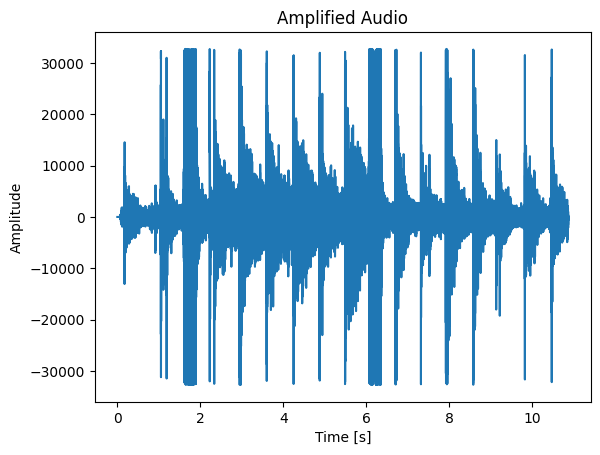

Amplified audio saved to amplified_audio.wav


In [36]:

def amplifye(file_path, amplification_factor=3):
    a = read_wav(file_path)
    sample_rate, data_array = a['sample_rate'], a['samples']
    
    if isinstance(data_array, np.ndarray):
        data_array = [data_array]
    
    amplified_data = [np.array(channel, dtype=np.float32) * amplification_factor for channel in data_array]
    
    max_val = 40000
    min_val = -40000
    amplified_data = [np.clip(channel, min_val, max_val) for channel in amplified_data]
    
    amplified_data = [channel.astype(np.int16) for channel in amplified_data]
    
    x_axis = np.arange(0, len(amplified_data[0])) / sample_rate 
    plt.plot(x_axis, amplified_data[0])
    plt.title("Amplified Audio")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.show()

    output_file = "amplified_audio.wav"
    
    with wave.open(output_file, 'wb') as out_wave_file:
        num_channels = len(amplified_data) 
        out_wave_file.setnchannels(num_channels)
        out_wave_file.setsampwidth(2)  
        out_wave_file.setframerate(sample_rate)
        
        for i in range(len(amplified_data[0])): 
            for channel in amplified_data:
                out_wave_file.writeframes(struct.pack('<h', channel[i]))
    
    print(f"Amplified audio saved to {output_file}")

amplifye("whistle/whistling-staircase.wav")


In [24]:
a = read_wav("whistle/begin-whistle.wav")
a

IS STEREO 1


{'sample_rate': 48000,
 'sample_width': 2,
 'num_channels': 1,
 'samples': array([ 0.000e+00,  1.000e+00, -2.000e+00, ..., -1.368e+03, -1.215e+03,
        -6.230e+02], dtype=float32)}

IS STEREO 1
IS STEREO 1


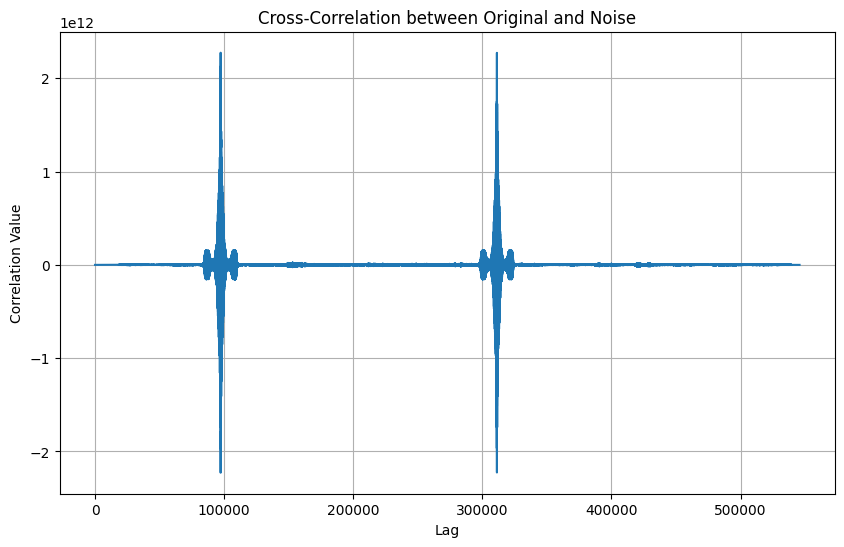

Maximum correlation found at lag: 73114


73114

In [41]:
def cross_correlation(original_signal, noise_signal):
    """
    Cross-correlates the original_signal with the noise_signal to find matching locations
    """
    copy_original_signal = original_signal.copy()
    copy_noise_signal = noise_signal.copy()
    
    
    copy_original_signal = copy_original_signal - np.mean(copy_original_signal)
    copy_noise_signal = copy_noise_signal - np.mean(copy_noise_signal)
    
    correlation = np.correlate(copy_original_signal, copy_noise_signal, mode='full')  
    lag = np.argmax(np.abs(correlation)) - len(copy_noise_signal) + 1
    return correlation, lag

def plot_correlation(correlation):
    """Plot the cross-correlation result"""
    plt.figure(figsize=(10, 6))
    plt.plot(correlation)
    plt.title('Cross-Correlation between Original and Noise')
    plt.xlabel('Lag')
    plt.ylabel('Correlation Value')
    plt.grid(True)
    plt.show()

def identify_noise_location(original_signal, noise_signal):
    correlation, lag = cross_correlation(original_signal, noise_signal)
    
    plot_correlation(correlation)
    
    print(f"Maximum correlation found at lag: {lag}")
    return lag, correlation

original_data = read_wav('whistle/whistling-staircase.wav')
noise_data = read_wav('whistle/remove/whistle-simple.wav')

original_signal = original_data['samples']
noise_signal = noise_data['samples']

lag, correlation = identify_noise_location(original_signal, noise_signal)
lag

In [ ]:
def save_wav(signal, sample_rate, output_file):
    """Saves the denoised signal to a new WAV file."""
    with wave.open(output_file, 'wb') as f:
        f.setnchannels(1) 
        f.setsampwidth(2) 
        f.setframerate(sample_rate)
        f.writeframes(signal.tobytes())

def remove_noise_using_correlation(original_signal, noise_signal, lag):
    """
    Remove the noise from the original signal based on the correlation lag
    """
    denoised_signal = original_signal.copy()
    
    if lag > 0:
        denoised_signal[lag:lag+len(noise_signal)] -= noise_signal
    elif lag < 0:
        denoised_signal[0:len(noise_signal)+lag] -= noise_signal[:len(noise_signal)+lag]
    else:
        denoised_signal[:len(noise_signal)] -= noise_signal

    return denoised_signal


denoised_signal = remove_noise_using_correlation(original_signal, noise_signal, lag)

save_wav(denoised_signal, original_data['sample_rate'], "denoised_output.wav")



IS STEREO 1
IS STEREO 1
Noise extracted and saved to extracted_noise.wav


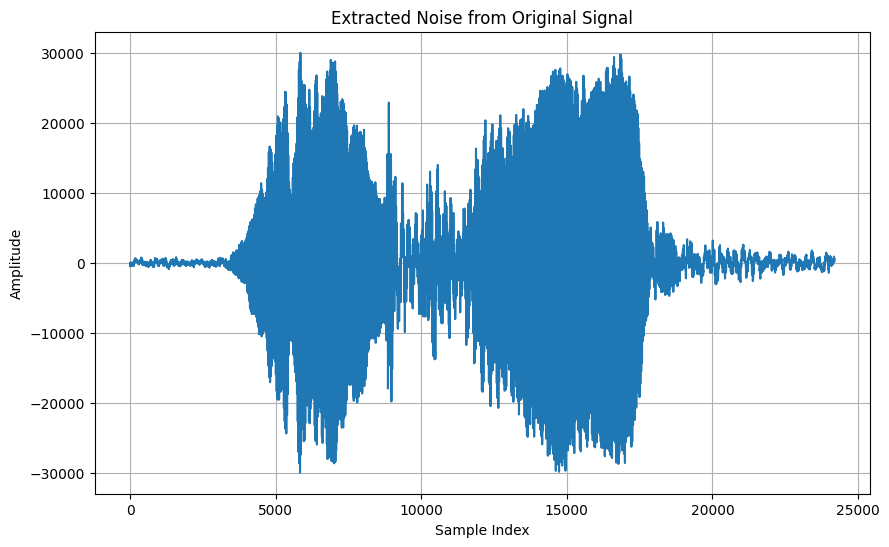

In [ ]:

def extract_noise_from_original(original_signal, noise_signal, lag):
    """
    Extracts the noise from the original signal based on the calculated lag.
    """
    noise_length = len(noise_signal)
    
    if lag > 0:
        noise_segment = original_signal[lag:lag + noise_length]
    elif lag < 0:
        noise_segment = original_signal[0:noise_length + lag]
    else:
        noise_segment = original_signal[0:noise_length]

    return noise_segment

def write_wav(file_path, sample_rate, samples, num_channels, sample_width):
    """
    Write samples to a WAV file.
    """
    with wave.open(file_path, 'wb') as out_wave_file:
        out_wave_file.setnchannels(num_channels) 
        out_wave_file.setsampwidth(sample_width) 
        out_wave_file.setframerate(sample_rate) 
        
        if sample_width == 1:
            out_wave_file.writeframes(np.array(samples, dtype=np.int8).tobytes())
        elif sample_width == 2:
            out_wave_file.writeframes(np.array(samples, dtype=np.int16).tobytes())
        elif sample_width == 4:
            out_wave_file.writeframes(np.array(samples, dtype=np.int32).tobytes())
        else:
            raise ValueError("Unsupported sample width")

def process_and_extract_noise(original_data, noise_data, lag):
    original_signal = original_data['samples']
    noise_signal = noise_data['samples']
    sample_rate = original_data['sample_rate']
    num_channels = original_data['num_channels']
    sample_width = original_data['sample_width']

    extracted_noise = extract_noise_from_original(original_signal, noise_signal, lag)
    
    output_noise_file = "extracted_noise.wav"
    write_wav(output_noise_file, sample_rate, extracted_noise, num_channels, sample_width)
    print(f"Noise extracted and saved to {output_noise_file}")
    
    plt.figure(figsize=(10, 6))
    plt.plot(extracted_noise)
    plt.title("Extracted Noise from Original Signal")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

original_data = read_wav('whistle/whistling-staircase.wav')
noise_data = read_wav('whistle/remove/whistle-simple.wav')

process_and_extract_noise(original_data, noise_data, lag)

IS STEREO 1
IS STEREO 1
Noise detected at index 73114
Noise detected at index 287078
Noise detected at index 397586
Noise detected at index 462205
Noise detected at index 496219


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


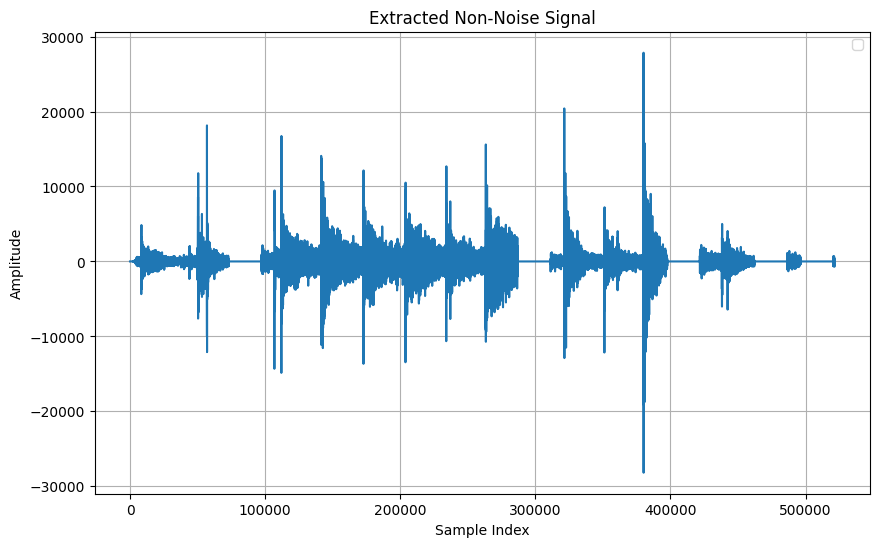

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

def sliding_window_non_noise_extraction(original_signal, noise_signal, lag, noise_length):
    """
    Extracts the non-noise portion of the signal by masking the noise using a sliding window approach.
    Returns a copy with masked noise regions.
    """
    non_noise_segment = original_signal.copy()
    
    start = max(lag, 0)
    end = min(lag + noise_length, len(original_signal))
    
    if start < end:
        non_noise_segment[start:end] = 0 
        
    return non_noise_segment

def cross_correlation(signal, template):
    """Compute cross-correlation and find maximum position."""
    corr = np.correlate(signal - np.mean(signal), 
                       template - np.mean(template), 
                       mode='valid')
    lag = np.argmax(np.abs(corr))
    return corr, lag

def process_and_extract_non_noise(original_data, noise_data, threshold=0.5):
    original_signal = original_data['samples']
    noise_signal = noise_data['samples']
    sample_rate = original_data['sample_rate']
    num_channels = original_data['num_channels']
    sample_width = original_data.get('sample_width', 2) 
    
    if num_channels > 1:
        extracted_signals = []
        for ch in range(num_channels):
            channel_signal = original_signal[ch] if isinstance(original_signal, list) else original_signal
            extracted = _process_single_channel(channel_signal, noise_signal, threshold)
            extracted_signals.append(extracted)
        extracted_signal = extracted_signals
    else:
        extracted_signal = _process_single_channel(original_signal, noise_signal, threshold)
    
    output_non_noise_file = "extracted_non_noise_multiple.wav"
    write_wav(output_non_noise_file, sample_rate, extracted_signal, num_channels, sample_width)
    
    plt.figure(figsize=(10, 6))
    if num_channels > 1:
        for ch_idx, ch_signal in enumerate(extracted_signal):
            plt.plot(ch_signal, label=f'Channel {ch_idx+1}')
    else:
        plt.plot(extracted_signal)
    plt.title("Extracted Non-Noise Signal")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()
    plt.show()

def _process_single_channel(signal, noise_template, threshold):
    """Process a single audio channel."""
    signal = np.array(signal)
    noise_template = np.array(noise_template)
    noise_length = len(noise_template)
    
    extracted = signal.copy()
    start_idx = 0
    
    while start_idx < len(extracted) - noise_length:
        current_segment = extracted[start_idx:start_idx + len(extracted) - noise_length]
        
        corr, lag = cross_correlation(current_segment, noise_template)
        max_corr = np.max(np.abs(corr))
        abs_lag = start_idx + lag
        
        if max_corr > threshold * np.max(np.abs(noise_template)):
            print(f"Noise detected at index {abs_lag}")
            
            extracted = sliding_window_non_noise_extraction(
                extracted, 
                noise_template, 
                abs_lag, 
                noise_length
            )
            start_idx = abs_lag + noise_length
        else:
            start_idx += max(1, noise_length // 2) 
            
    return extracted

original_data = read_wav('whistle/whistling-staircase.wav')
noise_data = read_wav('whistle/remove/whistle-simple.wav')
process_and_extract_non_noise(original_data, noise_data, threshold=0.7)